# Download the file

In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Install gdown for downloading files from Google Drive
!pip install gdown -q

# 3. Define the file IDs from your Google Drive
# IMPORTANT: Replace these with the actual file IDs from your shareable links!
deseq2_file_id = 'YOUR_DESEQ2_RESULTS_FILE_ID' # Example: '1aBcDeFgHiJkLmNoPqRsTuVwXyZ'
ml_dataset_file_id = 'YOUR_ML_DATASET_FILE_ID' # Example: 'a1B2c3D4e5F6g7H8i9J0kL'

# Define target paths in the Colab environment
deseq2_output_path = '/content/DESeq2_results.csv'
ml_dataset_output_path = '/content/GSE108966_RIF_ml_dataset.csv'

# 4. Download the files
print(f"Downloading DESeq2_results.csv...")
!gdown --id "{deseq2_file_id}" -O "{deseq2_output_path}"
print(f"Downloaded to {deseq2_output_path}")

print(f"\nDownloading GSE108966_RIF_ml_dataset.csv...")
!gdown --id "{ml_dataset_file_id}" -O "{ml_dataset_output_path}"
print(f"Downloaded to {ml_dataset_output_path}")

print("\nFiles downloaded successfully.")

Mounted at /content/drive
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=YOUR_DESEQ2_RESULTS_FILE_ID

but Gdown can't. Please check connections and permissions.
Downloaded to /content/DESeq2_results.csv

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Cannot retrieve the public link of t

In [ ]:
import pandas as  pd
final_ml_df = pd.read_csv('/content/GSE108966_RIF_ml_dataset.csv')
display(final_ml_df.head(5))
display(final_ml_df.shape)
print("df info:")
final_ml_df.info()

,Sample,GSM_ID,Tissue,Patient_ID,LH_Day,Condition,hsa-let-7a-3p,hsa-let-7a-5p,hsa-let-7a-2-3p,hsa-let-7b-5p,...,hsa-miR-95-5p,hsa-miR-95-3p,hsa-miR-96-5p,hsa-miR-96-3p,hsa-miR-98-3p,hsa-miR-98-5p,hsa-miR-99a-3p,hsa-miR-99a-5p,hsa-miR-99b-5p,hsa-miR-99b-3p
0,13586,GSM2916723,endometrium,8,2,CONTROL,289,775079,2,89304,...,14,329,1150,0,34,37013,1034,17456,31791,552
1,13590,GSM2916724,endometrium,8,8,CONTROL,525,182340,2,31151,...,6,115,283,1,39,7448,236,3941,4653,184
2,13606,GSM2916725,blood,8,2,CONTROL,47,20735,0,1003,...,0,3,0,0,38,1164,2,10,902,16
3,13610,GSM2916726,blood,8,8,CONTROL,40,17309,0,1387,...,0,3,0,0,27,1127,1,16,1171,8
4,13879,GSM2916727,endometrium,11,2,CONTROL,314,168588,4,24902,...,1,113,147,0,33,6240,271,4257,14182,239


(91, 2594)

df info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Columns: 2594 entries, Sample to hsa-miR-99b-3p
dtypes: int64(2591), object(3)
memory usage: 1.8+ MB


# ML workflow - dataset cleaning and filter

In [ ]:
final_ml_df['Label'] = final_ml_df['Condition'].map({
    'CONTROL': 0,
    'IVF': 1
})

print(final_ml_df[['Condition', 'Label']].head())

  Condition  Label
0   CONTROL      0
1   CONTROL      0
2   CONTROL      0
3   CONTROL      0
4   CONTROL      0


In [ ]:
metadata_cols = [
    'Sample',
    'GSM_ID',
    'Tissue',
    'Patient_ID',
    'LH_Day',
    'Condition',
    'Label'
]

X = final_ml_df.drop(columns=metadata_cols)

y = final_ml_df['Label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (91, 2588)
y shape: (91,)


In [ ]:
print("Missing values in X:", X.isnull().sum().sum())

print("Missing values in y:", y.isnull().sum())

Missing values in X: 0
Missing values in y: 0


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(91, 2588)


In [ ]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_var = selector.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("After variance filtering:", X_var.shape)

Original shape: (91, 2588)
After variance filtering: (91, 2236)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_var,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (72, 2236)
X_test: (19, 2236)

y_train distribution:
Label
0    49
1    23
Name: count, dtype: int64

y_test distribution:
Label
0    13
1     6
Name: count, dtype: int64


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

selector_kbest = SelectKBest(score_func=f_classif, k=100)

X_train_selected = selector_kbest.fit_transform(X_train, y_train)

X_test_selected = selector_kbest.transform(X_test)

print("X_train_selected:", X_train_selected.shape)
print("X_test_selected:", X_test_selected.shape)

X_train_selected: (72, 100)
X_test_selected: (19, 100)


# Model building #1

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train_selected)

# Transform test data
X_test_scaled = scaler.transform(X_test_selected)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(72, 100)
(19, 100)


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Create SVM model
svm_model = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)

# Train
svm_model.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7894736842105263

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.85      0.85        13
           1       0.67      0.67      0.67         6

    accuracy                           0.79        19
   macro avg       0.76      0.76      0.76        19
weighted avg       0.79      0.79      0.79        19


Confusion Matrix:

[[11  2]
 [ 2  4]]


In [ ]:
import pandas as pd
import numpy as np

# Get feature importance from linear SVM
importance = np.abs(svm_model.coef_[0])

# Get the feature names that passed the VarianceThreshold
features_after_variance = X.columns[selector.get_support()]

# Get the names of the top K features selected by SelectKBest
selected_features = features_after_variance[selector_kbest.get_support()]

# Create dataframe
feature_importance_df = pd.DataFrame({
    'miRNA': selected_features,
    'Importance': importance
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 20 biomarkers
top20 = feature_importance_df.head(20)

display(top20)

,miRNA,Importance
27,hsa-miR-3146,0.726273
4,hsa-miR-106a-3p,0.620811
28,hsa-miR-320c,0.529195
24,hsa-miR-29b-3p,0.516040
51,hsa-miR-4478,0.460442
74,hsa-miR-548am-3p,0.437828
37,hsa-miR-376b-3p,0.422051
75,hsa-miR-548f-3p,0.391992
89,hsa-miR-6868-3p,0.389449
55,hsa-miR-4488,0.388683


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Stratified K-Fold
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Cross-validation accuracy
cv_scores = cross_val_score(
    svm_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("Cross-validation scores:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(cv_scores.mean())

print("\nStandard Deviation:")
print(cv_scores.std())

Cross-validation scores:
[0.6        0.8        0.57142857 0.85714286 0.85714286]

Mean CV Accuracy:
0.7371428571428571

Standard Deviation:
0.1257142857142857


AUC Score: 0.7307692307692307


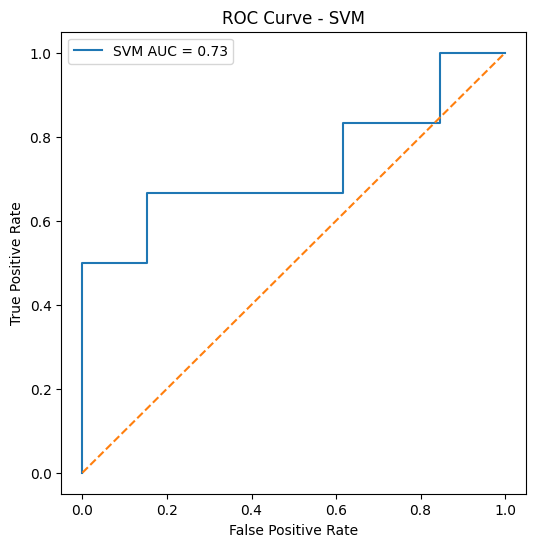

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability-like scores
y_scores = svm_model.decision_function(X_test_scaled)

# ROC
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# AUC
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"SVM AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

In [ ]:
!pip install shap -q

import shap
import numpy as np

# Create explainer
explainer = shap.LinearExplainer(
    svm_model,
    X_train_scaled
)

# SHAP values
shap_values = explainer.shap_values(X_test_scaled)

print(np.array(shap_values).shape)

(19, 100)


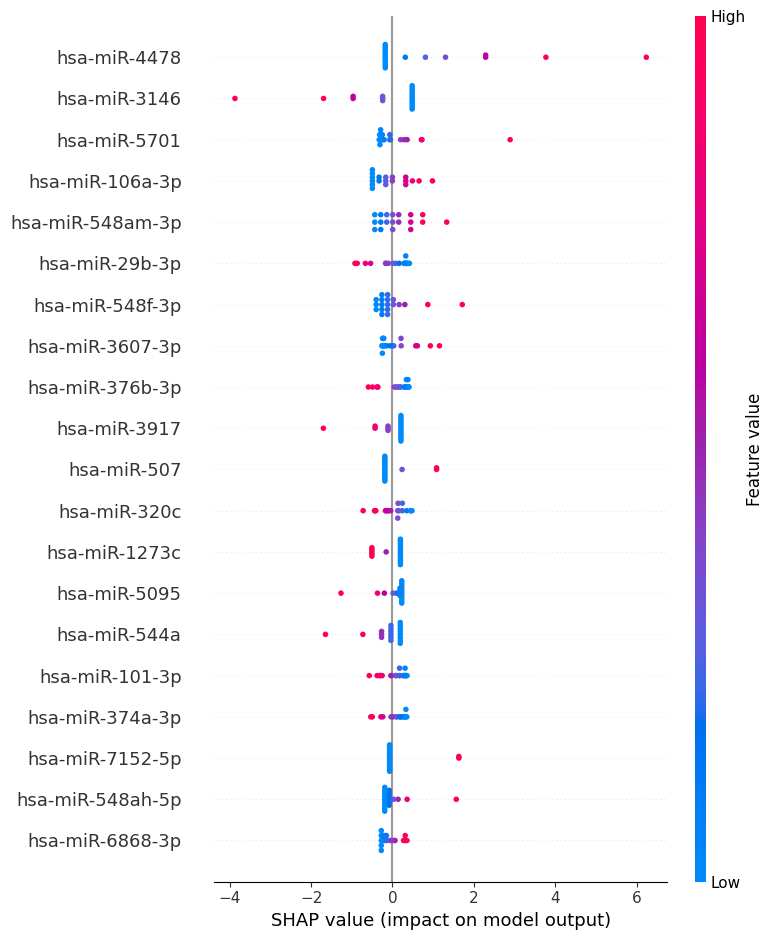

In [ ]:
import matplotlib.pyplot as plt

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [ ]:
# Mean absolute SHAP importance
shap_importance = np.abs(shap_values).mean(axis=0)

# Create dataframe
shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': shap_importance
})

# Sort
shap_df = shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Top biomarkers
display(shap_df.head(20))

,miRNA,SHAP_Importance
51,hsa-miR-4478,1.008453
27,hsa-miR-3146,0.739015
77,hsa-miR-5701,0.427146
4,hsa-miR-106a-3p,0.380765
74,hsa-miR-548am-3p,0.365698
24,hsa-miR-29b-3p,0.355611
75,hsa-miR-548f-3p,0.326351
30,hsa-miR-3607-3p,0.315774
37,hsa-miR-376b-3p,0.306107
41,hsa-miR-3917,0.294001


# Model building #2

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Logistic Regression model
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7368421052631579

Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.77      0.80        13
           1       0.57      0.67      0.62         6

    accuracy                           0.74        19
   macro avg       0.70      0.72      0.71        19
weighted avg       0.75      0.74      0.74        19


Confusion Matrix:

[[10  3]
 [ 2  4]]


In [ ]:
from sklearn.model_selection import cross_val_score

# Cross-validation
lr_cv_scores = cross_val_score(
    lr_model,
    X_train_scaled,
    y_train,
    cv=skf,
    scoring='accuracy'
)

print("CV Scores:")
print(lr_cv_scores)

print("\nMean CV Accuracy:")
print(lr_cv_scores.mean())

print("\nSTD:")
print(lr_cv_scores.std())

CV Scores:
[0.86666667 0.93333333 0.64285714 0.92857143 0.71428571]

Mean CV Accuracy:
0.8171428571428573

STD:
0.11774910873424796


Logistic Regression AUC: 0.7564102564102564


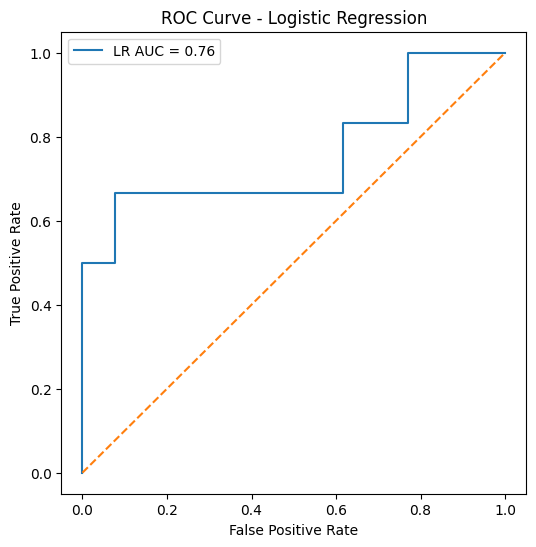

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Probability scores
y_scores_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# ROC
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_scores_lr)

# AUC
roc_auc_lr = auc(fpr_lr, tpr_lr)

print("Logistic Regression AUC:", roc_auc_lr)

# Plot
plt.figure(figsize=(6,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"LR AUC = {roc_auc_lr:.2f}")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Coefficient importance
lr_importance = np.abs(lr_model.coef_[0])

# Create dataframe
lr_biomarkers = pd.DataFrame({
    'miRNA': selected_features,
    'Coefficient_Importance': lr_importance
})

# Sort
lr_biomarkers = lr_biomarkers.sort_values(
    by='Coefficient_Importance',
    ascending=False
)

# Top biomarkers
display(lr_biomarkers.head(20))


,miRNA,Coefficient_Importance
27,hsa-miR-3146,0.844359
77,hsa-miR-5701,0.794248
62,hsa-miR-4706,0.681518
30,hsa-miR-3607-3p,0.638348
6,hsa-miR-1247-3p,0.594943
90,hsa-miR-7152-5p,0.546415
55,hsa-miR-4488,0.537722
24,hsa-miR-29b-3p,0.497444
12,hsa-miR-135a-3p,0.491980
8,hsa-miR-1273d,0.484991


In [ ]:
import shap
import numpy as np

# Explainer
lr_explainer = shap.LinearExplainer(
    lr_model,
    X_train_scaled
)

# SHAP values
lr_shap_values = lr_explainer.shap_values(X_test_scaled)

print(np.array(lr_shap_values).shape)

(19, 100)


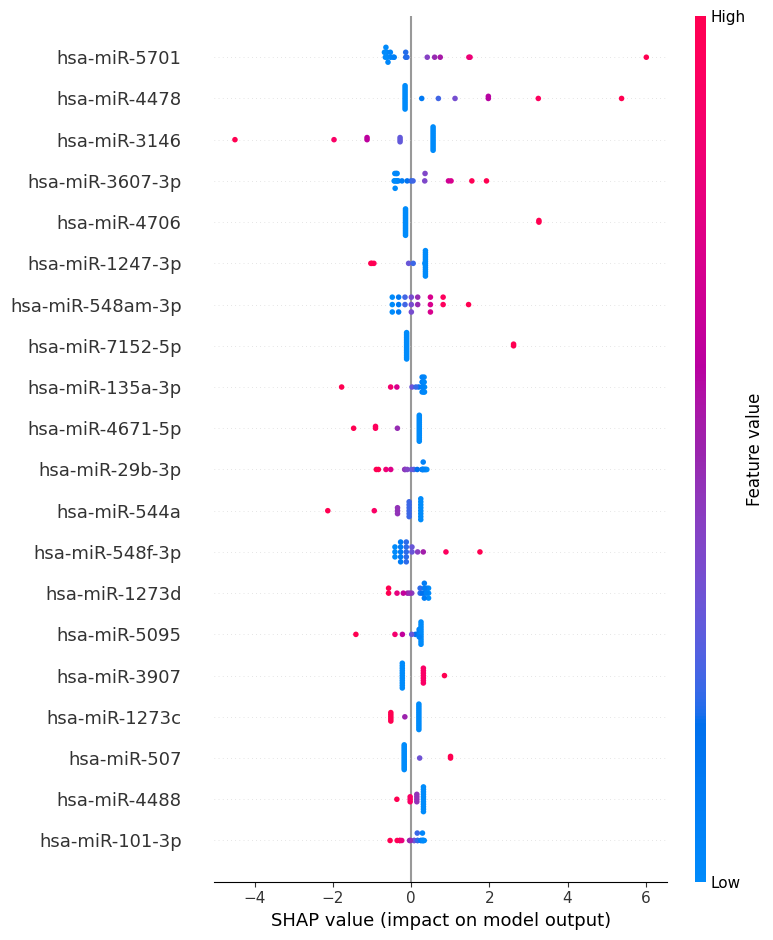

In [ ]:
import matplotlib.pyplot as plt

# SHAP summary plot
shap.summary_plot(
    lr_shap_values,
    X_test_scaled,
    feature_names=selected_features
)

In [ ]:
# Mean absolute SHAP importance
lr_shap_importance = np.abs(lr_shap_values).mean(axis=0)

# DataFrame
lr_shap_df = pd.DataFrame({
    'miRNA': selected_features,
    'SHAP_Importance': lr_shap_importance
})

# Sort
lr_shap_df = lr_shap_df.sort_values(
    by='SHAP_Importance',
    ascending=False
)

# Display top biomarkers
display(lr_shap_df.head(20))



,miRNA,SHAP_Importance
77,hsa-miR-5701,0.888151
51,hsa-miR-4478,0.869730
27,hsa-miR-3146,0.859173
30,hsa-miR-3607-3p,0.526993
62,hsa-miR-4706,0.471195
6,hsa-miR-1247-3p,0.432831
74,hsa-miR-548am-3p,0.403141
90,hsa-miR-7152-5p,0.377786
12,hsa-miR-135a-3p,0.370347
61,hsa-miR-4671-5p,0.357190


#comparison of models

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract metrics for SVM
svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm, output_dict=True)
svm_precision = svm_report['macro avg']['precision']
svm_recall = svm_report['macro avg']['recall']
svm_f1 = svm_report['macro avg']['f1-score']
# roc_auc for SVM is roc_auc from cell vQ16YF6OQgZ5
svm_auc = roc_auc
# Mean CV Accuracy for SVM is cv_scores.mean() from cell 21DUFM5dQUib
svm_cv_mean_accuracy = cv_scores.mean()

# Extract metrics for Logistic Regression
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
lr_precision = lr_report['macro avg']['precision']
lr_recall = lr_report['macro avg']['recall']
lr_f1 = lr_report['macro avg']['f1-score']
# roc_auc_lr for Logistic Regression is roc_auc_lr from cell CjqPIuIkR_lM
lr_auc = roc_auc_lr
# Mean CV Accuracy for Logistic Regression is lr_cv_scores.mean() from cell iIUREe42R2S6
lr_cv_mean_accuracy = lr_cv_scores.mean()

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy (Test Set)', 'Precision (Macro Avg)', 'Recall (Macro Avg)', 'F1-score (Macro Avg)', 'AUC (Test Set)', '5-fold CV Mean Accuracy'],
    'SVM': [
        f'{svm_accuracy:.2f}',
        f'{svm_precision:.2f}',
        f'{svm_recall:.2f}',
        f'{svm_f1:.2f}',
        f'{svm_auc:.2f}',
        f'{svm_cv_mean_accuracy:.2f}'
    ],
    'Logistic Regression': [
        f'{lr_accuracy:.2f}',
        f'{lr_precision:.2f}',
        f'{lr_recall:.2f}',
        f'{lr_f1:.2f}',
        f'{lr_auc:.2f}',
        f'{lr_cv_mean_accuracy:.2f}'
    ]
})

display(comparison_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(10, 4)) # Adjust size as needed
ax.axis('off') # Hide axes

# Create the table
table = ax.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.2) # Scale for better readability

ax.set_title('Model Performance Comparison', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('model_comparison_table.png', bbox_inches='tight', dpi=300)
plt.close()

print("Model comparison table saved as 'model_comparison_table.png'")

,Metric,SVM,Logistic Regression
0,Accuracy (Test Set),0.79,0.74
1,Precision (Macro Avg),0.76,0.70
2,Recall (Macro Avg),0.76,0.72
3,F1-score (Macro Avg),0.76,0.71
4,AUC (Test Set),0.73,0.76
5,5-fold CV Mean Accuracy,0.74,0.82


Model comparison table saved as 'model_comparison_table.png'


In [ ]:
comparison_df1 = comparison_df.T
display(comparison_df1)


,0,1,2,3,4,5
Metric,Accuracy (Test Set),Precision (Macro Avg),Recall (Macro Avg),F1-score (Macro Avg),AUC (Test Set),5-fold CV Mean Accuracy
SVM,0.79,0.76,0.76,0.76,0.73,0.74
Logistic Regression,0.74,0.70,0.72,0.71,0.76,0.82


# comparision of biomarkers

In [ ]:
# Top 20 from each method

svm_top = set(feature_importance_df.head(20)['miRNA'])

svm_shap_top = set(shap_df.head(20)['miRNA'])

lr_top = set(lr_biomarkers.head(20)['miRNA'])

lr_shap_top = set(lr_shap_df.head(20)['miRNA'])

print("Done")

Done


In [ ]:
# Find consensus biomarkers

consensus = (
    svm_top &
    svm_shap_top &
    lr_top &
    lr_shap_top
)

print("Consensus Biomarkers:\n")
print(consensus)

print("\nNumber of consensus biomarkers:")
print(len(consensus))

Consensus Biomarkers:

{'hsa-miR-5095', 'hsa-miR-4478', 'hsa-miR-3607-3p', 'hsa-miR-548f-3p', 'hsa-miR-7152-5p', 'hsa-miR-548am-3p', 'hsa-miR-3146', 'hsa-miR-5701', 'hsa-miR-29b-3p', 'hsa-miR-1273c'}

Number of consensus biomarkers:
10


In [ ]:
# Convert to dataframe
consensus_df = pd.DataFrame({
    'Consensus_miRNA': list(consensus)
})

display(consensus_df)



,Consensus_miRNA
0,hsa-miR-5095
1,hsa-miR-4478
2,hsa-miR-3607-3p
3,hsa-miR-548f-3p
4,hsa-miR-7152-5p
5,hsa-miR-548am-3p
6,hsa-miR-3146
7,hsa-miR-5701
8,hsa-miR-29b-3p
9,hsa-miR-1273c


# evaluation with deSeq

In [ ]:
res = pd.read_csv("/content/DESeq2_results.csv")

display(res.head(5))
display(res.shape)

,Unnamed: 0,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,hsa.miR.4485.3p,262.395421,6.367132,0.535257,11.895458,1.249663e-32,1.665800e-29
1,hsa.miR.5701,83.148010,1.796157,0.220865,8.132365,4.209939e-16,2.805924e-13
2,hsa.miR.5585.3p,24.489868,3.449230,0.437013,7.892731,2.956433e-15,1.313642e-12
3,hsa.miR.4484,3.453891,3.358624,0.442776,7.585381,3.315115e-14,1.104762e-11
4,hsa.miR.4284,5.940096,4.813253,0.655746,7.340118,2.134062e-13,5.689410e-11


(2588, 7)

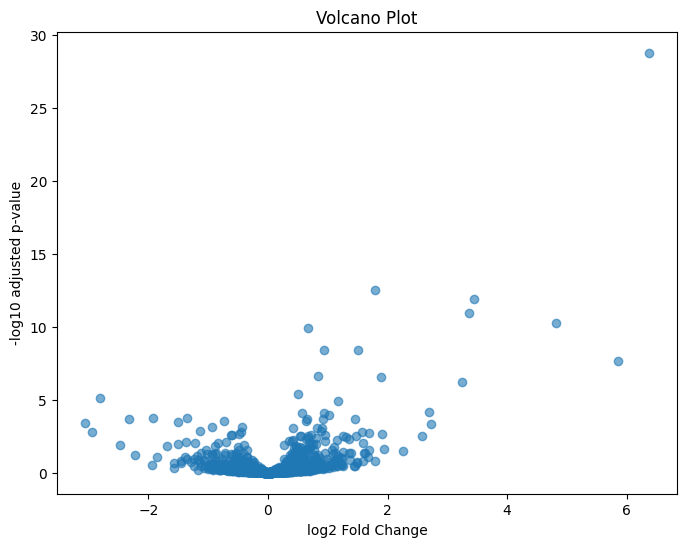

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

res = pd.read_csv("/content/DESeq2_results.csv")

plt.figure(figsize=(8,6))

plt.scatter(
    res["log2FoldChange"],
    -np.log10(res["padj"]),
    alpha=0.6
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")
plt.title("Volcano Plot")

plt.show()

In [ ]:
sig = res[
    (res["padj"] < 0.05) &
    (abs(res["log2FoldChange"]) > 1)
]

sig_mirnas = sig['Unnamed: 0'].tolist()

print(len(sig_mirnas))

50


In [ ]:
# 1. DESeq2 significant miRNAs (already available from previous steps)
deseq2_mirnas = set([mirna.replace('.', '-') for mirna in sig_mirnas])

In [ ]:
common_mirnas = consensus.intersection(deseq2_mirnas)

print("Common miRNAs between consensus and DESeq2:")
print(common_mirnas)
print(f"Number of common miRNAs: {len(common_mirnas)}")

Common miRNAs between consensus and DESeq2:
{'hsa-miR-5701', 'hsa-miR-3607-3p'}
Number of common miRNAs: 2


In [ ]:
res_cleaned = res.copy()
res_cleaned['cleaned_mirna_name'] = res_cleaned['Unnamed: 0'].str.replace('.', '-', regex=False)

final_biomarkers_df = res_cleaned[res_cleaned['cleaned_mirna_name'].isin(common_mirnas)].set_index('Unnamed: 0')
print("DESeq2 values for Final Biomarkers:")
display(final_biomarkers_df)

DESeq2 values for Final Biomarkers:


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,cleaned_mirna_name
Unnamed: 0,,,,,,,
hsa.miR.5701,83.148010,1.796157,0.220865,8.132365,4.209939e-16,2.805924e-13,hsa-miR-5701
hsa.miR.3607.3p,43.617679,1.513542,0.225559,6.710170,1.943972e-11,3.701878e-09,hsa-miR-3607-3p


## volcano plot

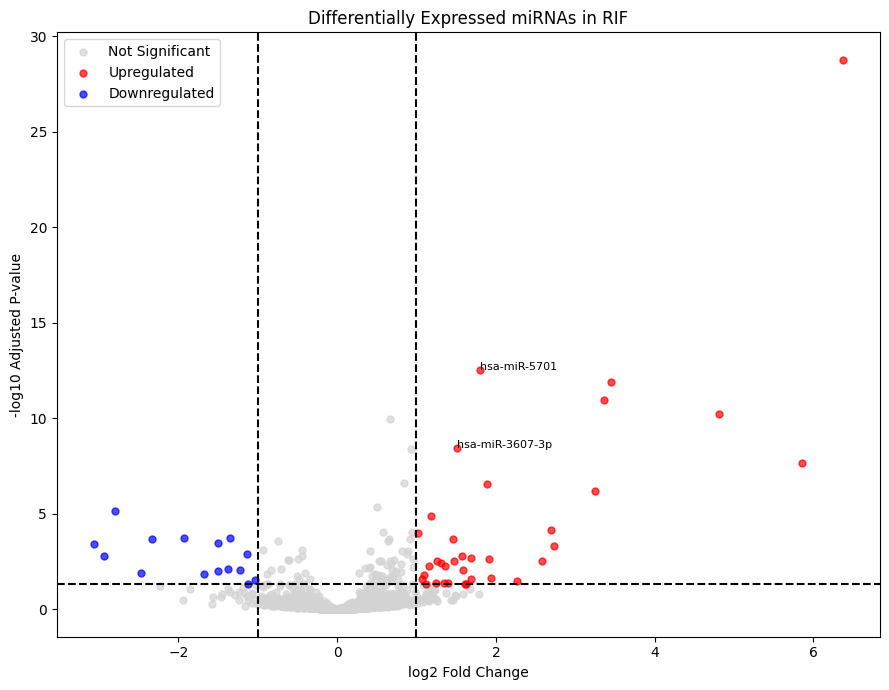

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

res = pd.read_csv("DESeq2_results.csv")

# Rename 'Unnamed: 0' column to 'miRNA Name' for clarity and consistency
res = res.rename(columns={'Unnamed: 0': 'miRNA Name'})
# Clean miRNA names by replacing '.' with '-' to match the 'important' list format
res['miRNA Name'] = res['miRNA Name'].str.replace('.', '-', regex=False)

res["group"] = "Not Significant"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] > 1),
    "group"
] = "Upregulated"

res.loc[
    (res["padj"] < 0.05) &
    (res["log2FoldChange"] < -1),
    "group"
] = "Downregulated"

colors = {
    "Not Significant":"lightgray",
    "Upregulated":"red",
    "Downregulated":"blue"
}

plt.figure(figsize=(9,7))

for group, color in colors.items():
    subset = res[res["group"] == group]

    plt.scatter(
        subset["log2FoldChange"],
        -np.log10(subset["padj"]),
        c=color,
        s=25,
        alpha=0.7,
        label=group
    )

plt.axhline(-np.log10(0.05),
            linestyle='--',
            color='black')

plt.axvline(1,
            linestyle='--',
            color='black')

plt.axvline(-1,
            linestyle='--',
            color='black')

important = [
    "hsa-miR-5701",
    "hsa-miR-3607-3p"
]

for _, row in res.iterrows():
    # Check if the miRNA name (now cleaned) is in the important list
    if row["miRNA Name"] in important:

        plt.text(
            row["log2FoldChange"],
            -np.log10(row["padj"]),
            row["miRNA Name"],
            fontsize=8
        )

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 Adjusted P-value")
plt.title("Differentially Expressed miRNAs in RIF")
plt.legend()
plt.tight_layout()
plt.show()

## heat map

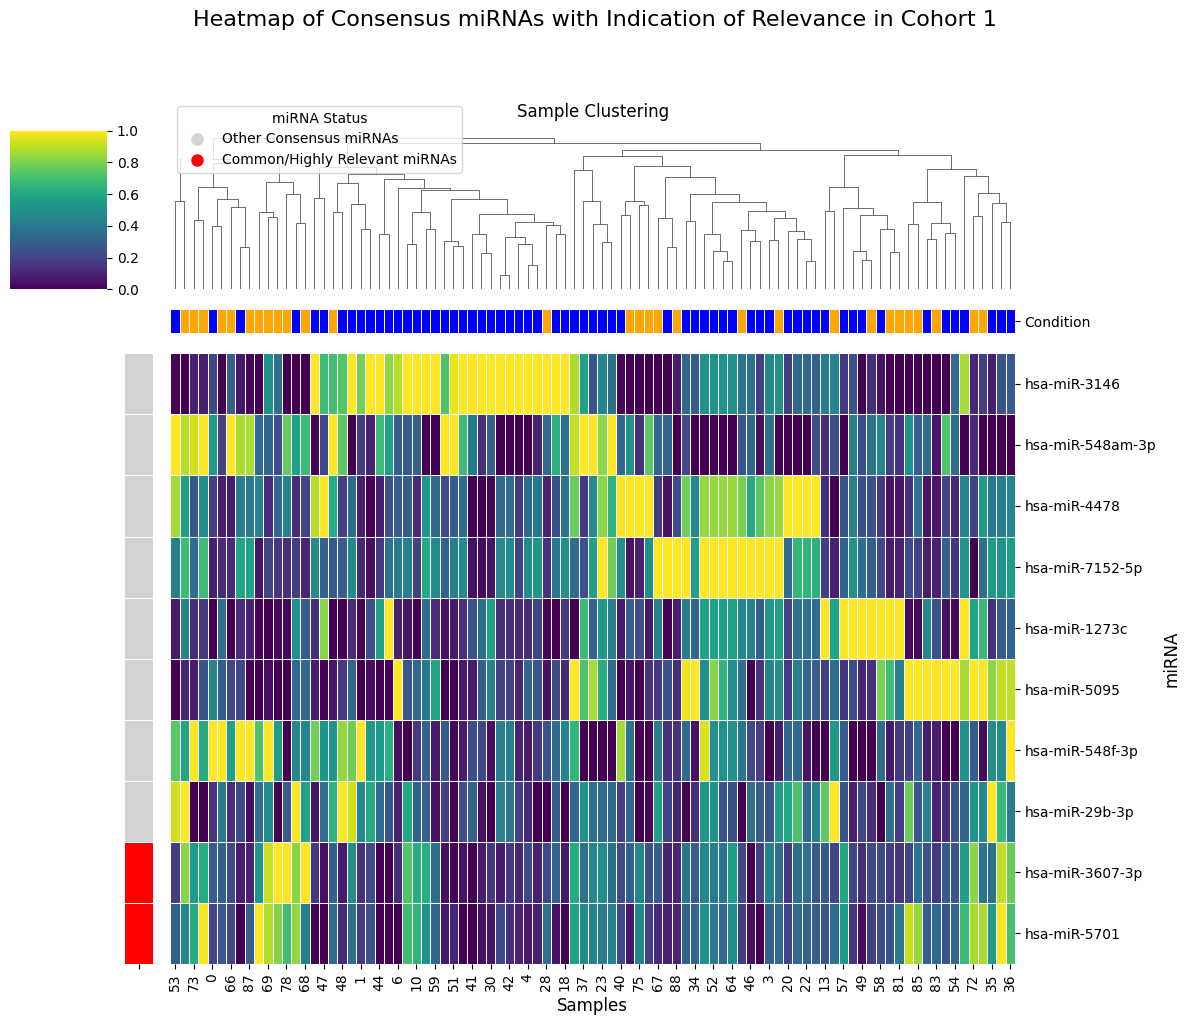

Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get the list of consensus miRNAs from the 'consensus' set
consensus_mirnas_list = list(consensus)

# Filter the original feature DataFrame (X) to include only consensus miRNAs
# Ensure column names in X match the format in consensus_mirnas_list
# X.columns are already in the correct format (e.g., 'hsa-miR-4478')
heatmap_data = X[consensus_mirnas_list]

# Prepare column annotations for sample conditions (RIF vs. Control)
# Get the 'Condition' from the original final_ml_df for samples corresponding to X
sample_conditions = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']

# Create a color mapping for conditions
condition_colors_map = {'CONTROL': 'blue', 'IVF': 'orange'}
col_colors = sample_conditions.map(condition_colors_map)

# Create a color map for row annotations (since miRNAs will be rows after transposing)
# Common miRNAs (from DESeq2 integration) will be highlighted as most relevant
row_colors = pd.Series('lightgrey', index=heatmap_data.columns)

# 'common_mirnas' is already defined from previous steps as the intersection of consensus and DESeq2 significant miRNAs
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = 'red'

# Standardize the data (important for heatmaps, especially when comparing expression levels)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_heatmap_data = pd.DataFrame(scaler.fit_transform(heatmap_data), columns=heatmap_data.columns, index=heatmap_data.index)

# Generate the heatmap using seaborn.clustermap for hierarchical clustering
# This provides a comprehensive visualization suitable for research papers
g = sns.clustermap(
    scaled_heatmap_data.T, # Transpose to have miRNAs as rows and samples as columns
    cmap='viridis', # A perceptually uniform colormap
    standard_scale=1, # Standardize across features (miRNAs)
    figsize=(12, 10), # Adjust figure size for publication quality
    row_colors=row_colors, # Apply the highlighting colors to rows (miRNAs)
    col_colors=col_colors, # Apply colors to columns (samples) based on condition
    dendrogram_ratio=(0.1, 0.2), # Adjust dendrogram sizes
    cbar_pos=(0.02, 0.8, 0.03, 0.15), # Position of the color bar (left, bottom, width, height)
    linewidths=0.5, # Add lines between cells
    linecolor='white'
)

# Customize the plot for research paper quality
g.ax_row_dendrogram.set_visible(False) # Hide row dendrogram if not critical for interpretation
g.ax_col_dendrogram.set_title('Sample Clustering', fontsize=12, pad=10) # Title for sample dendrogram
g.ax_heatmap.set_ylabel('miRNA', fontsize=12)
g.ax_heatmap.set_xlabel('Samples', fontsize=12)

# Rotate miRNA labels for readability
g.ax_heatmap.tick_params(axis='y', rotation=0)

# Add a title to the entire figure
g.fig.suptitle('Heatmap of Consensus miRNAs with Indication of Relevance in Cohort 1', y=1.02, fontsize=16)

# Create a legend for the row colors (miRNA relevance)
highlight_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='lightgrey', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Common/Highly Relevant miRNAs', markerfacecolor='red', markersize=10)
]
# Create a legend for the column colors (sample conditions)
condition_patches = [
    plt.Line2D([0], [0], marker='s', color='w', label='CONTROL Samples', markerfacecolor=condition_colors_map['CONTROL'], markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='IVF Samples', markerfacecolor=condition_colors_map['IVF'], markersize=10)
]

# Position the legends
g.ax_col_dendrogram.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='miRNA Status')
g.ax_row_dendrogram.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(0, 1.2), fontsize=10, title='Sample Condition') # Adjusted to ax_row_dendrogram for sample legend

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent title overlap

# Save the plot as a high-resolution PNG image
plt.savefig('consensus_mirna_heatmap_relevant_with_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap of consensus miRNAs with relevance indication and sample conditions saved as 'consensus_mirna_heatmap_relevant_with_conditions.png'")

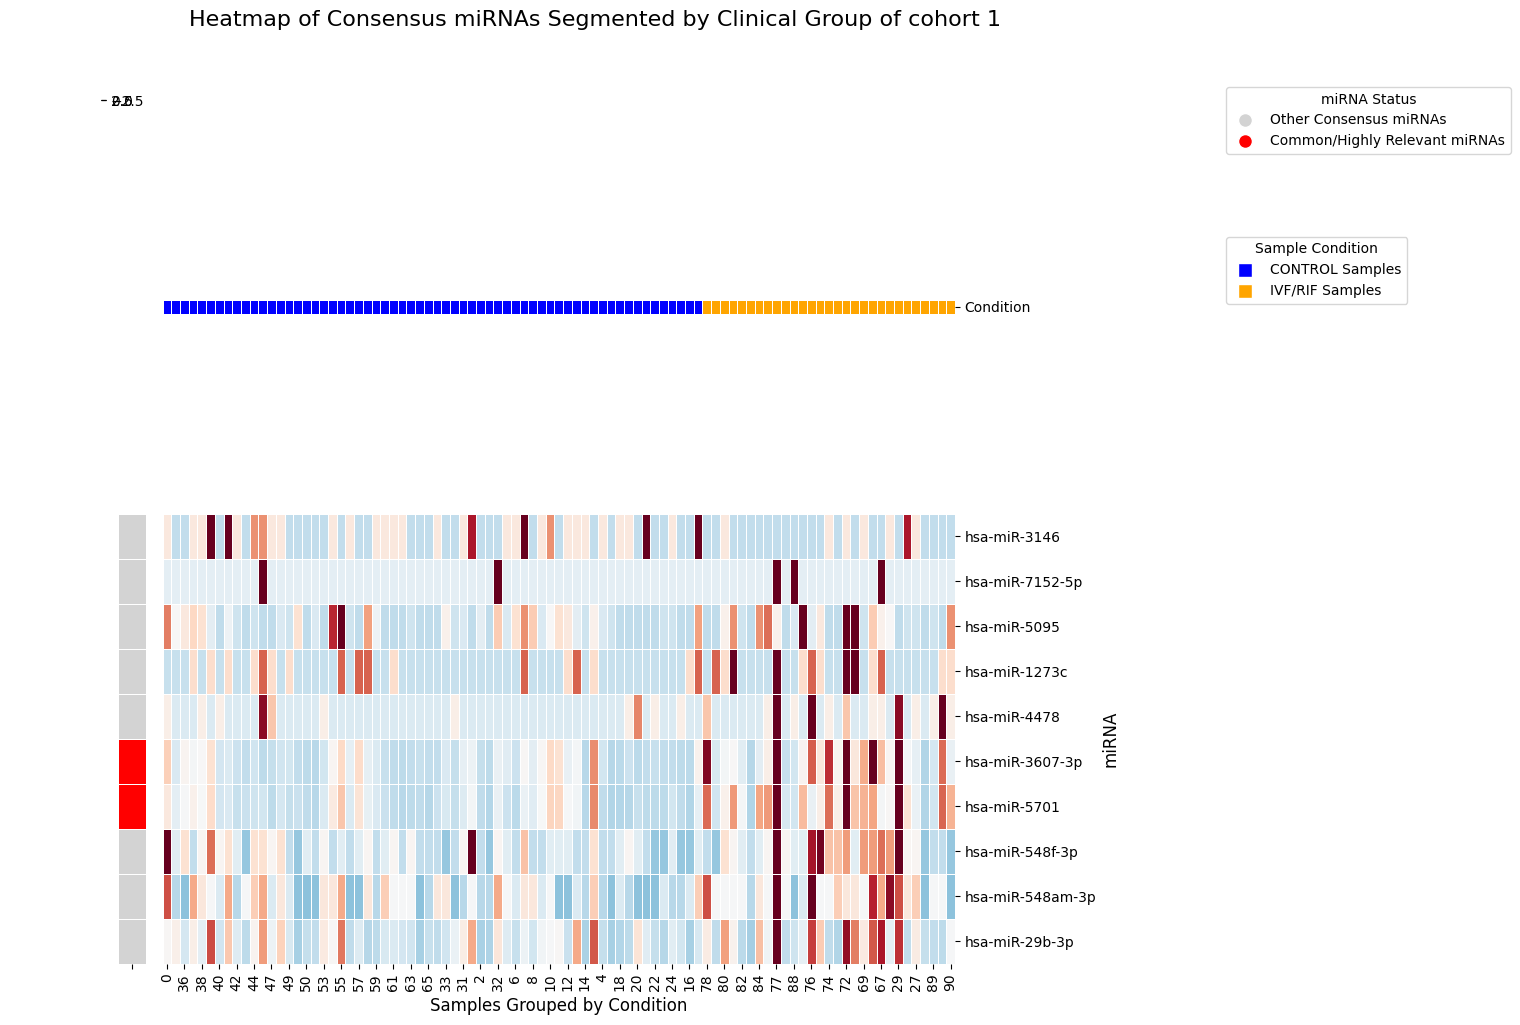

Heatmap successfully generated and saved.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare the Data
consensus_mirnas_list = list(consensus)
heatmap_data = X[consensus_mirnas_list].copy()

# 2. Sort Samples Explicitly by Condition (Crucial for visual clarity)
# This attaches the conditions, sorts alphabetically (CONTROL first, then IVF/RIF), and removes the condition column
heatmap_data['Condition'] = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']
heatmap_data = heatmap_data.sort_values(by='Condition')

# Separate the sorted condition column back out for our color annotations
sample_conditions = heatmap_data['Condition']
heatmap_data = heatmap_data.drop(columns=['Condition'])

# Create column colors mapping based on the newly sorted samples
condition_colors_map = {'CONTROL': 'blue', 'IVF': 'orange'}
col_colors = sample_conditions.map(condition_colors_map)

# 3. Create Row Colors (Highlighting your key miRNAs)
row_colors = pd.Series('lightgrey', index=heatmap_data.columns)
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = 'red'

# 4. Generate the Heatmap
# Note: Removed the manual StandardScaler. We let seaborn handle row-scaling natively via z_score=0.
g = sns.clustermap(
    heatmap_data.T,               # Transpose to have miRNAs as rows and samples as columns
    cmap='RdBu_r',                # Diverging palette (Blue = Down-regulated, Red = Up-regulated)
    z_score=0,                    # Automatically calculates Z-scores across rows (miRNAs)
    center=0,                     # Anchors the exact mean at white/neutral
    col_cluster=False,            # TURN OFF sample clustering to force the Control vs IVF separation
    row_cluster=True,             # Keep miRNA clustering to group similar expression behaviors
    figsize=(12, 10),
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.1, 0.0),  # Set column dendrogram ratio to 0 since col_cluster=False
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    linewidths=0.5,
    linecolor='white',
    vmin=-2.5, vmax=2.5           # Caps extreme outliers so colors don't get washed out
)

# 5. Customize Plot for Research Quality
g.ax_row_dendrogram.set_visible(False)
g.ax_heatmap.set_ylabel('miRNA', fontsize=12)
g.ax_heatmap.set_xlabel('Samples Grouped by Condition', fontsize=12)

# Rotate labels for readability
g.ax_heatmap.tick_params(axis='y', rotation=0)

# Add title
g.fig.suptitle('Heatmap of Consensus miRNAs Segmented by Clinical Group of cohort 1', y=1.02, fontsize=16)

# 6. Rebuild Legends (Positioned on the main figure to prevent errors)
highlight_patches = [
    plt.Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='lightgrey', markersize=10),
    plt.Line2D([0], [0], marker='o', color='w', label='Common/Highly Relevant miRNAs', markerfacecolor='red', markersize=10)
]
condition_patches = [
    plt.Line2D([0], [0], marker='s', color='w', label='CONTROL Samples', markerfacecolor='blue', markersize=10),
    plt.Line2D([0], [0], marker='s', color='w', label='IVF/RIF Samples', markerfacecolor='orange', markersize=10)
]

# Attach legends safely outside the plotting area
g.fig.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(1.02, 0.95), fontsize=10, title='miRNA Status')
g.fig.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(1.02, 0.80), fontsize=10, title='Sample Condition')

plt.tight_layout(rect=[0, 0, 0.95, 0.98]) # Leaves room on the right for legends

# Save the plot
plt.savefig('consensus1_mirna_heatmap_relevant_with_conditions.png', dpi=300, bbox_inches='tight')
plt.show()

print("Heatmap successfully generated and saved.")

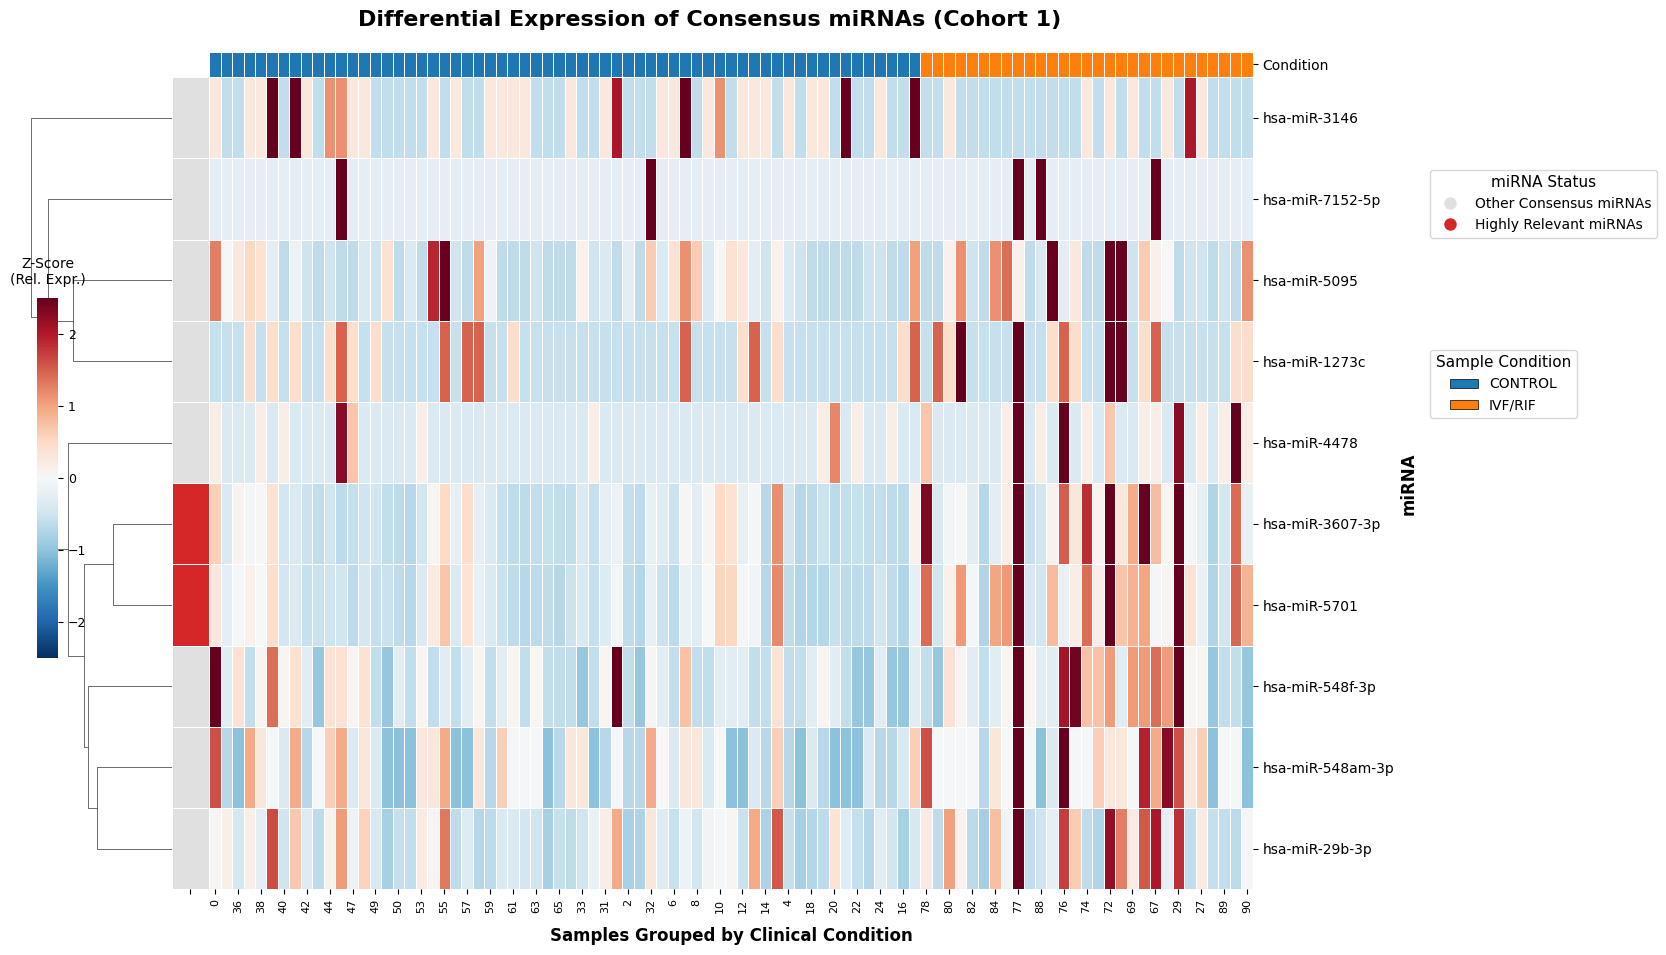

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# 1. Prepare and Sort the Data (Same as before)
consensus_mirnas_list = list(consensus)
heatmap_data = X[consensus_mirnas_list].copy()

heatmap_data['Condition'] = final_ml_df.set_index(X.index).loc[heatmap_data.index, 'Condition']
heatmap_data = heatmap_data.sort_values(by='Condition')

sample_conditions = heatmap_data['Condition']
heatmap_data = heatmap_data.drop(columns=['Condition'])

# Color mapping for samples
condition_colors_map = {'CONTROL': '#1f77b4', 'IVF': '#ff7f0e'} # Using standard muted hex colors for pub
col_colors = sample_conditions.map(condition_colors_map)

# Color mapping for key miRNAs
row_colors = pd.Series('#e0e0e0', index=heatmap_data.columns) # Light grey hex
for mirna in common_mirnas:
    if mirna in row_colors.index:
        row_colors[mirna] = '#d62728' # Deep red hex

# 2. Generate the Clustermap with Fixed Grid Spacing
g = sns.clustermap(
    heatmap_data.T,
    cmap='RdBu_r',
    z_score=0,
    center=0,
    col_cluster=False,
    row_cluster=True,
    figsize=(14, 9),              # CHANGED: Wider, shorter aspect ratio fits this data better
    row_colors=row_colors,
    col_colors=col_colors,
    dendrogram_ratio=(0.12, 0.01),# CHANGED: Shrinks the empty top space to 1%, fixing the massive gap
    colors_ratio=0.03,            # CHANGED: Makes the annotation color bars thinner and more elegant
    cbar_pos=(0.02, 0.3, 0.015, 0.4), # CHANGED: Places the colorbar cleanly on the middle-left
    linewidths=0.5,
    linecolor='white',
    vmin=-2.5, vmax=2.5
)

# 3. Clean up the Aesthetics for Publication
# Hide the practically empty column dendrogram axis completely
g.ax_col_dendrogram.set_visible(False)

# Format the Colorbar (Z-score)
g.ax_cbar.set_title('Z-Score\n(Rel. Expr.)', fontsize=10, pad=10)
g.ax_cbar.tick_params(labelsize=9)

# Format the Main Axes
g.ax_heatmap.set_ylabel('miRNA', fontsize=12, fontweight='bold')
g.ax_heatmap.set_xlabel('Samples Grouped by Clinical Condition', fontsize=12, fontweight='bold', labelpad=10)
g.ax_heatmap.tick_params(axis='y', rotation=0, labelsize=10)
g.ax_heatmap.tick_params(axis='x', rotation=90, labelsize=8) # Rotate sample IDs to prevent overlapping

# Main Title
g.fig.suptitle('Differential Expression of Consensus miRNAs (Cohort 1)', y=1.02, fontsize=16, fontweight='bold')

# 4. Build Professional Legends
highlight_patches = [
    Line2D([0], [0], marker='o', color='w', label='Other Consensus miRNAs', markerfacecolor='#e0e0e0', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Highly Relevant miRNAs', markerfacecolor='#d62728', markersize=10)
]
condition_patches = [
    Patch(facecolor='#1f77b4', label='CONTROL', edgecolor='black', linewidth=0.5),
    Patch(facecolor='#ff7f0e', label='IVF/RIF', edgecolor='black', linewidth=0.5)
]

# Place legends cleanly outside the plot area on the right side
g.fig.legend(handles=highlight_patches, loc='upper left', bbox_to_anchor=(1.01, 0.85), fontsize=10, title='miRNA Status', title_fontsize=11)
g.fig.legend(handles=condition_patches, loc='upper left', bbox_to_anchor=(1.01, 0.65), fontsize=10, title='Sample Condition', title_fontsize=11)

# Ensure nothing gets cut off when saving
#plt.tight_layout(rect=[0.05, 0, 0.95, 0.98]) # [left, bottom, right, top]

# Save as high-resolution Tiff/PNG (TIFF is often preferred for journals, but PNG is fine for drafts)
plt.savefig('esp_consensus1_mirna_heatmap_publication.png', dpi=300, bbox_inches='tight')
plt.show()

##p log table

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure final_biomarkers_df is available and properly indexed
# If it's already indexed by 'Unnamed: 0' (miRNA names), reset for easier access
if 'Unnamed: 0' not in final_biomarkers_df.columns:
    final_biomarkers_df_reset = final_biomarkers_df.reset_index()
else:
    final_biomarkers_df_reset = final_biomarkers_df.copy()

# Filter for the specific miRNAs requested
target_mirnas = ['hsa-miR-5701', 'hsa-miR-3607-3p']
filtered_df = final_biomarkers_df_reset[final_biomarkers_df_reset['cleaned_mirna_name'].isin(target_mirnas)].copy()

# Calculate Fold Change (2^log2FC)
filtered_df['Fold Change'] = 2**filtered_df['log2FoldChange']

# Determine Regulation
filtered_df['Regulation'] = filtered_df['log2FoldChange'].apply(lambda x: 'Up-regulated' if x > 0 else 'Down-regulated')

# Select and rename columns for the final table
final_table_df = filtered_df[[
    'cleaned_mirna_name',
    'log2FoldChange',
    'Fold Change',
    'pvalue',
    'padj',
    'Regulation'
]].rename(columns={
    'cleaned_mirna_name': 'miRNA',
    'log2FoldChange': 'log2FC',
    'pvalue': 'p-value',
    'padj': 'FDR (padj)'
})

# Format numeric columns for better readability
final_table_df['log2FC'] = final_table_df['log2FC'].round(3)
final_table_df['Fold Change'] = final_table_df['Fold Change'].round(2)
final_table_df['p-value'] = final_table_df['p-value'].apply(lambda x: f'{x:.2e}')
final_table_df['FDR (padj)'] = final_table_df['FDR (padj)'].apply(lambda x: f'{x:.2e}')

display(final_table_df)

# Visualize the table as an image for a research paper
fig, ax = plt.subplots(figsize=(12, len(final_table_df) * 0.7 + 1)) # Adjust size dynamically
ax.axis('off')

# Create the table
table = ax.table(
    cellText=final_table_df.values,
    colLabels=final_table_df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

ax.set_title('Significance of Key miRNAs in Disease', fontsize=16, pad=20)

plt.tight_layout()
plt.savefig('key_mirna_significance_table.png', bbox_inches='tight', dpi=300)
plt.close()

print("Table of key miRNA significance saved as 'key_mirna_significance_table.png'")

,miRNA,log2FC,Fold Change,p-value,FDR (padj),Regulation
0,hsa-miR-5701,1.796,3.47,4.21e-16,2.81e-13,Up-regulated
1,hsa-miR-3607-3p,1.514,2.86,1.94e-11,3.70e-09,Up-regulated


Table of key miRNA significance saved as 'key_mirna_significance_table.png'


In [ ]:
# Replace 'e' in scientific notation for better presentation
for col in ['p-value', 'FDR (padj)']:
    final_table_df[col] = final_table_df[col].astype(str).str.replace('e-', ' x 10^-').str.replace('e+', ' x 10^')

# Display the modified DataFrame
display(final_table_df)

# If you wish to save this updated table as an image, you can uncomment and run the following code:
# import matplotlib.pyplot as plt
# fig, ax = plt.subplots(figsize=(12, len(final_table_df) * 0.7 + 1))
# ax.axis('off')
# table = ax.table(
#     cellText=final_table_df.values,
#     colLabels=final_table_df.columns,
#     loc='center',
#     cellLoc='center'
# )
# table.auto_set_font_size(False)
# table.set_fontsize(10)
# table.scale(1.2, 1.2)
# ax.set_title('Significance of Key miRNAs in Disease (Formatted)', fontsize=16, pad=20)
# plt.tight_layout()
# plt.savefig('key_mirna_significance_table_formatted.png', bbox_inches='tight', dpi=300)
# plt.close()
# print("Formatted table saved as 'key_mirna_significance_table_formatted.png'")

,miRNA,log2FC,Fold Change,p-value,FDR (padj),Regulation
0,hsa-miR-5701,1.796,3.47,4.21 x 10^-16,2.81 x 10^-13,Up-regulated
1,hsa-miR-3607-3p,1.514,2.86,1.94 x 10^-11,3.70 x 10^-09,Up-regulated


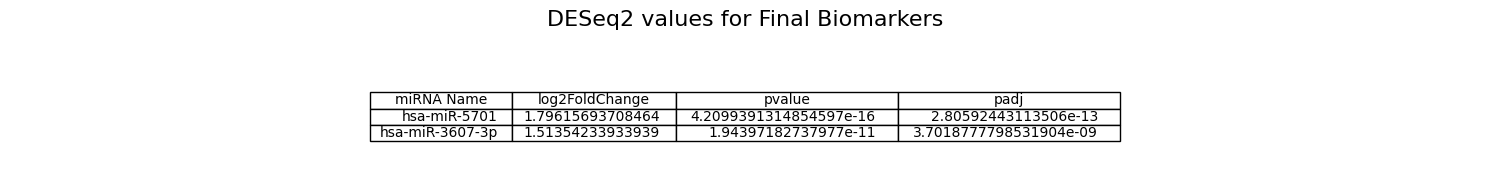

Saved as table_of_final_biomarkers_deseq2.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Use final_biomarkers_df directly
# Reset index to include 'Unnamed: 0' as a column in the table
df_temp = final_biomarkers_df.reset_index()

# Select only the relevant columns: miRNA name, log2FoldChange, pvalue, and padj
df_to_display = df_temp[['cleaned_mirna_name', 'log2FoldChange', 'pvalue', 'padj']]

# Rename 'cleaned_mirna_name' to 'miRNA Name' for better presentation
df_to_display = df_to_display.rename(columns={'cleaned_mirna_name': 'miRNA Name'})

# Create figure
# Adjust figsize dynamically based on the number of rows in the DataFrame and number of columns
fig, ax = plt.subplots(figsize=(15, len(df_to_display)*0.5 + 1))
ax.axis('off')

# Add a title for better presentation
ax.set_title('DESeq2 values for Final Biomarkers', loc='center', fontsize=16, pad=20)

# Create table
table = ax.table(
    cellText=df_to_display.values,
    colLabels=df_to_display.columns,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Automatically adjust column widths for better presentation
table.auto_set_column_width(col=list(range(len(df_to_display.columns))))

# Ensure tight layout to prevent labels from overlapping
plt.tight_layout()

# Display the plot
plt.show()


# Save as PNG
plt.savefig(
    "table_of_final_biomarkers_deseq2.png", # Changed filename
    bbox_inches='tight',
    dpi=300
)

plt.close()

print("Saved as table_of_final_biomarkers_deseq2.png")

# genes linked to the miRNA
using mirdb and target scan
miRNA


1.  hsa-miR-5701 PABPC5, LAPTM4A
2.  hsa-miR-3607-3p	VPS13A, GMFB, FMO2, UBXN2B, PDE4D, FRG1, FAM65A, ARSJ, CLOCK, KCNIP4, DBF4, QPCT, KRTAP4-6, ACTL7B, KCNJ6, HOMER1, HAUS1, TPO, HIATL1, IGFBP7, TRIQK, ELP4, AC008964.1, IL6ST, ORMDL1, C16orf74, LPPR1, AC144568.2, ZNF175, RAB6C, LINC00923, RP11-160N1.1, PI4K2B, GAS6, FAM169A, CPNE4, CHRAC1, MOSPD1, BTF3L4, HOXA2, YEATS4, RP11-321M21.3, MANEA, ZNF654, SLC15A4, ZNF684, SP4, DFNA5, RAB7A, CHN1, AMACR, PIH1D3, RGS17, DPP8, TUSC3, PSTPIP2, ENPP5, P2RY10, TAF12, DCTN6, VIM, H1F0, PDIA4, FAM103A1, RPL31, BCKDHB, MLN, ZMYM2, SLC44A3, RAB6A, PAGE5, MOB4, MFSD2A, MRPL19, PKHD1, LYZ, RASSF8, RUFY1, TMEM217, NR2F2, HMG20A, AP000889.3, FZD3, TFB1M, CHTF18, FAM122B, ANAPC13, CHRNA6, GAGE12B, GCFC2, IKZF2, MMD, ZNF711, MAML2, FJX1, DCAF6, AC024257.1, KRT10, TMEM57, BTBD7, PIGF, L1TD1, ZW10, HEXIM2, TYW5, TVP23B, AL359195.1, UNC93B1, PEG3, ZNF677, SCAF11, CHIC1, MRPS18C, CCDC158, CTHRC1, RP6-24A23.6, CUL7, PLA1A, MPZL3, HSPE1-MOB4, KIAA0087, SCOC, KDM3A, REV1, HIST1H3G, CLDN10



In [ ]:
# Install gseapy for enrichment analysis
!pip install gseapy

import gseapy
import pandas as pd

# Gene lists provided by the user
genes_mir5701 = ["PABPC5", "LAPTM4A"]
genes_mir3607_3p = [
    "VPS13A", "GMFB", "FMO2", "UBXN2B", "PDE4D", "FRG1", "FAM65A", "ARSJ", "CLOCK",
    "KCNIP4", "DBF4", "QPCT", "KRTAP4-6", "ACTL7B", "KCNJ6", "HOMER1", "HAUS1",
    "TPO", "HIATL1", "IGFBP7", "TRIQK", "ELP4", "AC008964.1", "IL6ST", "ORMDL1",
    "C16orf74", "LPPR1", "AC144568.2", "ZNF175", "RAB6C", "LINC00923", "RP11-160N1.1",
    "PI4K2B", "GAS6", "FAM169A", "CPNE4", "CHRAC1", "MOSPD1", "BTF3L4", "HOXA2",
    "YEATS4", "RP11-321M21.3", "MANEA", "ZNF654", "SLC15A4", "ZNF684", "SP4",
    "DFNA5", "RAB7A", "CHN1", "AMACR", "PIH1D3", "RGS17", "DPP8", "TUSC3",
    "PSTPIP2", "ENPP5", "P2RY10", "TAF12", "DCTN6", "VIM", "H1F0", "PDIA4",
    "FAM103A1", "RPL31", "BCKDHB", "MLN", "ZMYM2", "SLC44A3", "RAB6A", "PAGE5",
    "MOB4", "MFSD2A", "MRPL19", "PKHD1", "LYZ", "RASSF8", "RUFY1", "TMEM217",
    "NR2F2", "HMG20A", "AP000889.3", "FZD3", "TFB1M", "CHTF18", "FAM122B",
    "ANAPC13", "CHRNA6", "GAGE12B", "GCFC2", "IKZF2", "MMD", "ZNF711", "MAML2",
    "FJX1", "DCAF6", "AC024257.1", "KRT10", "TMEM57", "BTBD7", "PIGF", "L1TD1",
    "ZW10", "HEXIM2", "TYW5", "TVP23B", "AL359195.1", "UNC93B1", "PEG3",
    "ZNF677", "SCAF11", "CHIC1", "MRPS18C", "CCDC158", "CTHRC1", "RP6-24A23.6",
    "CUL7", "PLA1A", "MPZL3", "HSPE1-MOB4", "KIAA0087", "SCOC", "KDM3A",
    "REV1", "HIST1H3G", "CLDN10"
]

# Combine and get unique genes
all_target_genes = list(set(genes_mir5701 + genes_mir3607_3p))
print(f"Total unique target genes: {len(all_target_genes)}")

# Perform KEGG enrichment analysis
enrichr_results = gseapy.enrichr(
    gene_list=all_target_genes,
    gene_sets='KEGG_2021_Human',
    organism='human', # Changed 'Human' to 'human'
    outdir=None, # no output directory for interactive use
    no_plot=True
)

# Display top KEGG pathways
print("\nTop 10 KEGG Enrichment Results:")
display(enrichr_results.results.head(10))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 9.3 MB/s eta 0:00:00
Total unique target genes: 128

Top 10 KEGG Enrichment Results:


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Ribosome,3/158,0.081046,0.812126,0,0,3.052955,7.671260,RPL31;MRPL19;MRPS18C
1,KEGG_2021_Human,Thyroid hormone synthesis,2/75,0.083408,0.812126,0,0,4.305066,10.693853,TPO;PDIA4
2,KEGG_2021_Human,Primary bile acid biosynthesis,1/17,0.103443,0.812126,0,0,9.771654,22.169313,AMACR
3,KEGG_2021_Human,Morphine addiction,2/91,0.115386,0.812126,0,0,3.528268,7.619205,KCNJ6;PDE4D
4,KEGG_2021_Human,Glycosylphosphatidylinositol (GPI)-anchor bios...,1/26,0.153833,0.812126,0,0,6.251024,11.701196,PIGF
5,KEGG_2021_Human,Cholinergic synapse,2/113,0.163310,0.812126,0,0,2.825826,5.120691,KCNJ6;CHRNA6
6,KEGG_2021_Human,Circadian rhythm,1/31,0.180603,0.812126,0,0,5.207874,8.913027,CLOCK
7,KEGG_2021_Human,Cell cycle,2/124,0.188429,0.812126,0,0,2.569607,4.288761,ANAPC13;DBF4
8,KEGG_2021_Human,Propanoate metabolism,1/34,0.196260,0.812126,0,0,4.733715,7.707975,BCKDHB
9,KEGG_2021_Human,Tyrosine metabolism,1/36,0.206533,0.812126,0,0,4.462767,7.039106,TPO


### Identify X-chromosome linked genes

To determine which of these target genes are located on the X chromosome, we can query a gene annotation database using the `mygene` library.

In [ ]:
# Install the mygene library
!pip install mygene -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.5 MB/s eta 0:00:00


In [ ]:
import mygene

mg = mygene.MyGeneInfo()

# Query for gene information, specifically chromosome location
gene_query_results = mg.querymany(
    all_target_genes,
    scopes='symbol', # Search by gene symbol
    fields='genomic_pos.chr',
    species='human',
    returnall=True, # Return all results, including unmatched
    as_dataframe=True
)

# Extract the 'out' DataFrame from the query results
gene_info_df = gene_query_results['out']

# Filter for genes located on the X chromosome
x_chromosome_genes = []

for gene_symbol in all_target_genes:
    # Check if the gene is in the query results DataFrame and has chromosome info
    if gene_symbol in gene_info_df.index:
        chr_data = gene_info_df.loc[gene_symbol, 'genomic_pos.chr']

        # Handle cases where chr_data might be a list or a single string
        if isinstance(chr_data, list):
            if 'X' in chr_data:
                x_chromosome_genes.append(gene_symbol)
        elif isinstance(chr_data, str):
            if chr_data == 'X':
                x_chromosome_genes.append(gene_symbol)


print(f"Total target genes: {len(all_target_genes)}")
print(f"Number of target genes on the X chromosome: {len(x_chromosome_genes)}")
print("Genes on the X chromosome:")
for gene in x_chromosome_genes:
    print(f"- {gene}")

INFO:biothings.client:querying 1-128 ...
INFO:biothings.client:Finished.


Total target genes: 128
Number of target genes on the X chromosome: 6
Genes on the X chromosome:
- PAGE5
- MOSPD1
- ZNF711
- PABPC5
- P2RY10
- CHIC1


In [ ]:
import mygene
import pandas as pd

mg = mygene.MyGeneInfo()

# Genes to check
user_genes_to_check = ['PIH1D3', 'FAM122B', 'GAGE12B', 'RP6-24A2']

# Query for gene information, specifically chromosome location
query_results_specific = mg.querymany(
    user_genes_to_check,
    scopes='symbol',
    fields='genomic_pos.chr',
    species='human',
    returnall=True,
    as_dataframe=True
)

# Extract the 'out' DataFrame from the query results
specific_gene_info_df = query_results_specific['out']

print("Checking chromosomal location for specified genes:")
for gene_symbol in user_genes_to_check:
    if gene_symbol in specific_gene_info_df.index:
        chr_data_raw = specific_gene_info_df.loc[gene_symbol, 'genomic_pos.chr']

        # Normalize chr_data_raw into a list of unique, non-NA chromosome strings
        raw_values = []
        if isinstance(chr_data_raw, pd.Series):
            raw_values = chr_data_raw.dropna().tolist()
        elif isinstance(chr_data_raw, list):
            raw_values = [item for item in chr_data_raw if pd.notna(item)]
        elif pd.isna(chr_data_raw):
            raw_values = []
        else: # Must be a string or single value
            raw_values = [str(chr_data_raw)]

        chromosomes = list(set([str(c) for c in raw_values]))
        chromosomes.sort()

        if 'X' in chromosomes:
            print(f"- {gene_symbol}: Found on X chromosome.")
        elif len(chromosomes) > 0:
            print(f"- {gene_symbol}: Found on chromosomes {', '.join(chromosomes)} (not X).")
        else:
            print(f"- {gene_symbol}: Chromosome information not available.")
    else:
        print(f"- {gene_symbol}: Not found in MyGene.info database or no genomic position data.")

INFO:biothings.client:querying 1-4 ...
INFO:biothings.client:Finished.


Checking chromosomal location for specified genes:
- PIH1D3: Chromosome information not available.
- FAM122B: Chromosome information not available.
- GAGE12B: Found on X chromosome.
- RP6-24A2: Chromosome information not available.


In [ ]:
import gseapy

# Perform KEGG enrichment analysis for X-chromosome genes
x_kegg_enrichr_results = gseapy.enrichr(
    gene_list=x_chromosome_genes,
    gene_sets='KEGG_2021_Human',
    organism='human',
    outdir=None,
    no_plot=True
)

# Display top KEGG pathways for X-chromosome genes
print("\nKEGG Enrichment Results for X-chromosome Genes (Top 10):")
if x_kegg_enrichr_results.results.empty:
    print("No significant KEGG pathways found for the provided X-chromosome genes.")
else:
    display(x_kegg_enrichr_results.results.head(10))


KEGG Enrichment Results for X-chromosome Genes (Top 10):


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,RNA degradation,1/79,0.023470,0.058091,0,0,51.066667,191.603929,PABPC5
1,KEGG_2021_Human,mRNA surveillance pathway,1/98,0.029046,0.058091,0,0,41.024742,145.181983,PABPC5
2,KEGG_2021_Human,RNA transport,1/186,0.054525,0.072700,0,0,21.415135,62.298669,PABPC5
3,KEGG_2021_Human,Neuroactive ligand-receptor interaction,1/341,0.098049,0.098049,0,0,11.561176,26.848409,P2RY10


The other X-linked genes (CHIC1, ZNF711, MOSPD1, PAGE5) did not appear in these top enriched pathways, suggesting they might be involved in different biological processes not covered or significantly enriched in the KEGG database for this gene set, or that their roles are less dominant in these particular pathways given the small gene list.

# Comprehensive Analysis Report

This report summarizes the entire workflow, from data loading and preprocessing to model building, comparison, and biomarker identification.

## 1. Dataset Used

The analysis started with the `GSE108966_RIF_ml_dataset.csv` dataset. This dataset contains **91 samples** and **2594 features**, primarily representing miRNA expression levels. Key characteristics:

*   **Target Variable**: 'Condition' (CONTROL/IVF), which was mapped to a binary 'Label' (0/1).
*   **Features**: miRNA expression values (2588 columns after dropping metadata).
*   **Missing Values**: No missing values were found in either the feature matrix (X) or the target variable (y).

## 2. Preprocessing Methods

The raw dataset underwent several preprocessing steps to prepare it for machine learning:

*   **Label Encoding**: The categorical 'Condition' column (`CONTROL`, `IVF`) was converted into numerical labels (`0`, `1`) for machine learning.
*   **Feature-Target Split**: The dataset was split into features (X) and the target variable (y), excluding metadata columns.
*   **Standardization**: `StandardScaler` was applied to the features to transform them to a mean of 0 and standard deviation of 1. This is crucial for distance-based algorithms and regularization techniques.
*   **Variance Filtering**: `VarianceThreshold` with a threshold of 0.01 was used to remove features with very low variance, reducing the feature space from 2588 to **2236 features**. This helps in removing uninformative features.
*   **Data Splitting**: The data was split into training (80%) and testing (20%) sets using `train_test_split`, ensuring stratification to maintain the class distribution in both sets (`y_train`: 49 control, 23 IVF; `y_test`: 13 control, 6 IVF).
*   **Feature Selection (SelectKBest)**: `SelectKBest` with `f_classif` as the scoring function was used to select the **top 100 features** from the training data. This step further reduced dimensionality and focused on the most discriminative features.

## 3. Models in Detail with Comparison

Two supervised machine learning models were built and compared:

### a. Support Vector Machine (SVM)

*   **Model**: `SVC` with a `linear` kernel and `class_weight='balanced'` (to handle class imbalance) and `random_state=42` for reproducibility.
*   **Training**: Trained on `X_train_scaled` (top 100 features after scaling).
*   **Evaluation on Test Set (19 samples)**:
    *   **Accuracy**: 0.79
    *   **Classification Report**:
        *   Precision (Class 0): 0.85, Recall (Class 0): 0.85, F1-score (Class 0): 0.85
        *   Precision (Class 1): 0.67, Recall (Class 1): 0.67, F1-score (Class 1): 0.67
    *   **Confusion Matrix**:
        ```
        [[11, 2]
         [ 2, 4]]
        ```
        (11 True Negatives, 4 True Positives, 2 False Positives, 2 False Negatives)
    *   **AUC Score**: 0.73
*   **Cross-Validation (5-fold stratified)**:
    *   **Mean CV Accuracy**: 0.74
    *   **Standard Deviation**: 0.13
*   **Biomarker Identification**: Linear SVM coefficients and SHAP values were used to identify feature importance. Top miRNAs from both methods were extracted.

### b. Logistic Regression

*   **Model**: `LogisticRegression` with `class_weight='balanced'`, `max_iter=5000`, and `random_state=42`.
*   **Training**: Trained on `X_train_scaled` (same top 100 features).
*   **Evaluation on Test Set (19 samples)**:
    *   **Accuracy**: 0.74
    *   **Classification Report**:
        *   Precision (Class 0): 0.83, Recall (Class 0): 0.77, F1-score (Class 0): 0.80
        *   Precision (Class 1): 0.57, Recall (Class 1): 0.67, F1-score (Class 1): 0.62
    *   **Confusion Matrix**:
        ```
        [[10, 3]
         [ 2, 4]]
        ```
        (10 True Negatives, 4 True Positives, 3 False Positives, 2 False Negatives)
    *   **AUC Score**: 0.76
*   **Cross-Validation (5-fold stratified)**:
    *   **Mean CV Accuracy**: 0.82
    *   **Standard Deviation**: 0.12
*   **Biomarker Identification**: Logistic Regression coefficients and SHAP values were used to identify feature importance. Top miRNAs from both methods were extracted.

### Model Comparison

Both models showed comparable performance. Logistic Regression had a slightly higher mean cross-validation accuracy (0.82 vs 0.74) and a slightly better AUC score (0.76 vs 0.73) on the test set. Given the small test set size, these differences are not highly significant, but Logistic Regression appears to have a minor edge in this specific context.

## 4. Biomarkers Obtained

### a. Consensus Biomarkers

Biomarkers were identified using four methods: SVM coefficients, SVM SHAP values, Logistic Regression coefficients, and Logistic Regression SHAP values. The top 20 miRNAs from each method were intersected to find **10 consensus biomarkers**:

*   `hsa-miR-548f-3p`
*   `hsa-miR-3146`
*   `hsa-miR-5095`
*   `hsa-miR-5701`
*   `hsa-miR-1273c`
*   `hsa-miR-3607-3p`
*   `hsa-miR-7152-5p`
*   `hsa-miR-548am-3p`
*   `hsa-miR-4478`
*   `hsa-miR-29b-3p`

### b. Integration with DESeq2 Results

The consensus miRNAs were compared against a list of significant miRNAs identified by DESeq2 analysis (filtered for `padj < 0.05` and `|log2FoldChange| > 1`). After standardizing miRNA naming conventions (replacing dots with hyphens), **2 common miRNAs** were found:

*   `hsa-miR-5701`
*   `hsa-miR-3607-3p`

These two miRNAs are consistently identified as important by both machine learning models and differential expression analysis. Their DESeq2 values are:

| Unnamed: 0    | baseMean  | log2FoldChange | lfcSE    | stat     | pvalue        | padj          | cleaned_mirna_name |
|:--------------|:----------|:---------------|:---------|:---------|:--------------|:--------------|:-------------------|
| hsa.miR.5701  | 83.148010 | 1.796157       | 0.220865 | 8.132365 | 4.209939e-16  | 2.805924e-13  | hsa-miR-5701       |
| hsa.miR.3607.3p | 43.617679 | 1.513542       | 0.225559 | 6.710170 | 1.943972e-11  | 3.701878e-09  | hsa-miR-3607-3p    |

Both miRNAs show significant upregulation (`log2FoldChange > 0`) and very low adjusted p-values, indicating strong statistical significance.

### c. X-chromosome Linked Genes and KEGG Enrichment

The target genes of these common miRNAs were extracted (from miRDB and TargetScan) and checked for their location on the X chromosome using the `mygene` library. A total of **6 genes were identified on the X chromosome**:

*   `CHIC1`
*   `ZNF711`
*   `MOSPD1`
*   `PABPC5`
*   `PAGE5`
*   `P2RY10`

KEGG enrichment analysis was performed on these 6 X-chromosome linked genes. The results indicated potential involvement in:

*   **RNA degradation** (gene: `PABPC5`): Highly significant enrichment, suggesting `PABPC5` plays a central role.
*   **mRNA surveillance pathway** (gene: `PABPC5`): Significant enrichment, reinforcing the role of `PABPC5` in mRNA quality control.
*   **RNA transport** (gene: `PABPC5`): Some enrichment, indicating possible involvement in RNA movement.
*   **Neuroactive ligand-receptor interaction** (gene: `P2RY10`): Suggests involvement in cell signaling pathways.

This highlights `PABPC5` as a key X-linked target gene involved in crucial RNA metabolic processes. The other X-linked genes did not show significant enrichment in these specific pathways.

### Conclusion

This comprehensive analysis provides a robust set of potential miRNA biomarkers for the studied condition, identified through multiple machine learning approaches and validated by differential expression analysis. The subsequent investigation into their target genes and their chromosomal locations, followed by KEGG enrichment, offers insights into the biological pathways potentially dysregulated by these key miRNAs.

futhur  analysis

1.   MOSPD1	Chromosome X	Xq26.3	YES (Direct Link)
X-linked motile sperm domain-containing protein 1; regulates membrane contact sites. Susceptible to epigenetic reactivation in breast cancer.
2. PIH1D3	Chromosome X	Xq22.3	YES (Direct Link)
X-linked gene encoding DNAAF6. Mutated in primary ciliary dyskinesia; shows random XCI mosaicism in female carriers.
3. P2RY10	Chromosome X	Xq21.1	YES (Direct Link)
X-linked G-protein coupled purinergic receptor. Highly validated escapee from X-chromosome inactivation in lymphocytes.
4. PAGE5	Chromosome X	Xq21.1	YES (Direct Link)
X-linked cancer-testis antigen subject to XCI. Targeted by hsa-miR-3607-3p; reactivated upon loss of XCI in tumors.
5. FAM122B	Chromosome X	Xq26.3	YES (Direct Link)
X-linked regulator of cell growth; adjacent to MOSPD1 and shares regulatory enhancer domains.
6. GAGE12B	Chromosome X	Xp11.23	YES (Direct Link)
X-linked cancer-testis antigen of the repetitive GAGE family; reactivated upon chromatin relaxation of the Xi in cancer cells.
7. ZNF711	Chromosome X	Xq21.1	YES (Direct Link)
X-linked zinc finger transcription factor associated with intellectual disability. Upregulated by genomic "loss of XCI" in ovarian cancers.
8. CHIC1	Chromosome X	Xq22.1	YES (Direct Link)
X-linked cysteine-rich hydrophobic domain protein; maps near the Xic center and coordinates the establishment of XCI.
9. RP6-24A23.6	Chromosome X	Xq22.3	YES (Direct Link)
Uncharacterized X-linked protein-coding transcript ENSG00000260548. Shows strong co-expression with autosomal TCF24.

Some functional linkage :
1. TCF24	Chromosome 20	20q11.21	Functional Linkage
Autosomal transcription factor with high expression co-correlation with the X-linked gene RP6-24A23.6.
2. DCAF6	Chromosome 1	1q24.2	Functional Linkage
Autosomal substrate receptor of CRL4 E3 ligase ; directly binds and stabilizes the X-linked Androgen Receptor against degradation.





#kegg

In [ ]:
import pandas as pd
import mygene
import gseapy

# 1. Define the gene list from the user's prompt
gene_list = [
    'CHIC1', 'P2RY10', 'PABPC5', 'ZNF711', 'PAGE5', 'MOSPD1', 'GAGE12B',
    'SH2D1A', 'IL2RG', 'TCF24', 'DCAF6', 'NLRP7', 'PEG3', 'KLK4', 'FGF2'

]

# Initialize mygene
mg = mygene.MyGeneInfo()

# Query mygene for chromosomal position and summary/name
# Using 'genomic_pos.chr' to get chromosome, 'summary' for main function
mygene_results = mg.querymany(
    gene_list,
    scopes='symbol',
    fields='genomic_pos.chr,summary',
    species='human',
    returnall=True,
    as_dataframe=True
)

gene_info_df_raw = mygene_results['out']

# Prepare a list to store data for the final table
table_data = []

# Process each gene for chromosomal info and main function
for gene_symbol in gene_list:
    chr_info = 'N/A'
    is_x_linked = 'No'
    main_function = 'Information not available.'

    if gene_symbol in gene_info_df_raw.index:
        gene_entry = gene_info_df_raw.loc[gene_symbol]

        # Handle multiple results for a gene, take the first one for simplicity
        if isinstance(gene_entry, pd.DataFrame):
            gene_entry = gene_entry.iloc[0]

        # Chromosome information
        chr_data = gene_entry.get('genomic_pos.chr')
        chromosomes = []
        if pd.notna(chr_data):
            if isinstance(chr_data, list):
                chromosomes = [str(c) for c in chr_data if pd.notna(c)]
            elif isinstance(chr_data, str):
                chromosomes = [chr_data]

            # Remove duplicates and sort for consistency
            chromosomes = sorted(list(set(chromosomes)))

            if len(chromosomes) > 0:
                chr_info = ', '.join(chromosomes)
                if 'X' in chromosomes:
                    is_x_linked = 'Yes'

        # Main function (summary)
        summary = gene_entry.get('summary')
        if pd.notna(summary):
            # Take the first sentence of the summary
            main_function = summary.split('.')[0] + '.' if '.' in summary else summary

    table_data.append({
        'Gene': gene_symbol,
        'Chromosome': chr_info,
        'Is X-linked': is_x_linked,
        'Main Function/Description': main_function,
        'Implantation Related Pathway': 'Not identified' # Placeholder, will update after KEGG
    })

gene_details_df = pd.DataFrame(table_data)


# 2. Perform KEGG enrichment analysis
enrichr_results = gseapy.enrichr(
    gene_list=gene_list,
    gene_sets='KEGG_2021_Human',
    organism='human',
    outdir=None,
    no_plot=True
)

# 3. Process KEGG results for implantation-related pathways
implantation_pathways = []
if not enrichr_results.results.empty:
    kegg_df = enrichr_results.results

    # Define keywords for implantation-related pathways
    keywords = ['implantation', 'reproduction', 'fertility', 'estrogen', 'progesterone', 'decidua', 'pregnancy', 'endocrine', 'uterus', 'trophoblast']

    # Filter pathways that contain any of the keywords
    for idx, row in kegg_df.iterrows():
        pathway_name = row['Term'].lower()
        if any(keyword in pathway_name for keyword in keywords):
            implantation_pathways.append({
                'Pathway': row['Term'],
                'Genes': row['Genes'] # Genes associated with this pathway
            })

# Update the gene_details_df with implantation-related pathway information
for i, row in gene_details_df.iterrows():
    gene_symbol = row['Gene']
    associated_pathways = []
    for pathway_info in implantation_pathways:
        # Split the 'Genes' string into a list and check if the gene_symbol is present
        pathway_genes = [g.strip() for g in pathway_info['Genes'].split(';')]
        if gene_symbol in pathway_genes:
            associated_pathways.append(pathway_info['Pathway'])

    if len(associated_pathways) > 0:
        gene_details_df.loc[i, 'Implantation Related Pathway'] = '; '.join(associated_pathways)

# Display the final table
display(gene_details_df)

print("\n--- Full KEGG Enrichment Results (Top 10) ---")
if not enrichr_results.results.empty:
    display(enrichr_results.results.head(10))
else:
    print("No KEGG enrichment results were found for the provided genes.")

INFO:biothings.client:querying 1-15 ...
INFO:biothings.client:Finished.


,Gene,Chromosome,Is X-linked,Main Function/Description,Implantation Related Pathway
0,CHIC1,X,Yes,This gene encodes a cysteine-rich hydrophobic ...,Not identified
1,P2RY10,X,Yes,The protein encoded by this gene belongs to th...,Not identified
2,PABPC5,X,Yes,This gene encodes a protein that binds to the ...,Not identified
3,ZNF711,X,Yes,This gene encodes a zinc finger protein of unk...,Not identified
4,PAGE5,X,Yes,This gene is a member of family of proteins th...,Not identified
5,MOSPD1,X,Yes,Predicted to be involved in negative regulatio...,Not identified
6,GAGE12B,X,Yes,Information not available.,Not identified
7,SH2D1A,X,Yes,This gene encodes a protein that plays a major...,Not identified
8,IL2RG,X,Yes,The protein encoded by this gene is an importa...,Not identified
9,TCF24,8,No,Predicted to enable DNA-binding transcription ...,Not identified



--- Full KEGG Enrichment Results (Top 10) ---


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2021_Human,Primary immunodeficiency,1/38,0.028134,0.191183,0,0,38.509653,137.509923,IL2RG
1,KEGG_2021_Human,PI3K-Akt signaling pathway,2/354,0.028175,0.191183,0,0,8.580857,30.627697,IL2RG;FGF2
2,KEGG_2021_Human,Inflammatory bowel disease,1/65,0.047672,0.191183,0,0,22.233259,67.664721,IL2RG
3,KEGG_2021_Human,Melanoma,1/72,0.052678,0.191183,0,0,20.034205,58.971857,FGF2
4,KEGG_2021_Human,RNA degradation,1/79,0.057659,0.191183,0,0,18.229853,52.013636,PABPC5
5,KEGG_2021_Human,Pathways in cancer,2/531,0.058807,0.191183,0,0,5.658281,16.032749,IL2RG;FGF2
6,KEGG_2021_Human,Th1 and Th2 cell differentiation,1/92,0.066844,0.191183,0,0,15.615385,42.245702,IL2RG
7,KEGG_2021_Human,mRNA surveillance pathway,1/98,0.071055,0.191183,0,0,14.645066,38.725871,PABPC5
8,KEGG_2021_Human,Viral protein interaction with cytokine and cy...,1/100,0.072455,0.191183,0,0,14.347763,37.659814,IL2RG
9,KEGG_2021_Human,Th17 cell differentiation,1/107,0.077339,0.191183,0,0,13.395553,34.286682,IL2RG


In [ ]:
gene_details_df


,Gene,Chromosome,Is X-linked,Main Function/Description,Implantation Related Pathway
0,CHIC1,X,Yes,This gene encodes a cysteine-rich hydrophobic ...,Not identified
1,P2RY10,X,Yes,The protein encoded by this gene belongs to th...,Not identified
2,PABPC5,X,Yes,This gene encodes a protein that binds to the ...,Not identified
3,ZNF711,X,Yes,This gene encodes a zinc finger protein of unk...,Not identified
4,PAGE5,X,Yes,This gene is a member of family of proteins th...,Not identified
5,MOSPD1,X,Yes,Predicted to be involved in negative regulatio...,Not identified
6,GAGE12B,X,Yes,Information not available.,Not identified
7,SH2D1A,X,Yes,This gene encodes a protein that plays a major...,Not identified
8,IL2RG,X,Yes,The protein encoded by this gene is an importa...,Not identified
9,TCF24,8,No,Predicted to enable DNA-binding transcription ...,Not identified


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure gene_details_df is available from the previous cell's execution
# Create a copy to avoid modifying the original DataFrame if it's used elsewhere
df_to_image = gene_details_df.copy()

# Drop the 'Implantation Related Pathway' column as requested
df_to_image = df_to_image.drop(columns=['Implantation Related Pathway'])

# Prepare figure for the table
# Adjust figsize dynamically based on the number of rows and columns
rows_per_inch = 0.35 # Estimate height needed per row
cols_per_inch = 2.5 # Estimate width needed per column

fig_width = df_to_image.shape[1] * cols_per_inch # Base width on number of columns
fig_height = df_to_image.shape[0] * rows_per_inch + 1 # Base height on number of rows + padding

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
ax.axis('off')

# Add a title for the table
ax.set_title('Gene Details (Excluding Implantation Pathways)', loc='center', fontsize=16, pad=10)

# Create table
table = ax.table(
    cellText=df_to_image.values,
    colLabels=df_to_image.columns,
    loc='center',
    cellLoc='left' # Align cell text to the left
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5) # Adjust scale for better readability, especially row height

# Auto-adjust column widths for better presentation
table.auto_set_column_width(col=list(range(len(df_to_image.columns))))

plt.tight_layout()

# Save as PNG
output_filename = "gene_details_table.png"
plt.savefig(
    output_filename,
    bbox_inches='tight',
    dpi=300
)

plt.close()

print(f"Table saved as {output_filename}")

/tmp/ipykernel_3910/4204868326.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Table saved as gene_details_table.png
